# 6. Interpretabilidade do Cenário B

Este notebook investiga quais variáveis utilizadas no Cenário B apresentam
maior importância para o modelo Gradient Boosting.

A análise utiliza os mesmos folds temporais e a mesma configuração do modelo
empregados no experimento principal.

Serão analisadas:

- importância interna do Gradient Boosting;
- importância por permutação no conjunto de teste;
- importância agregada por grupo de variáveis.

## 6.1 Configuração

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()

while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "src").is_dir()
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").is_dir():
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raiz do projeto: {PROJECT_ROOT}")

Raiz do projeto: /home/sara/Documentos/tcc-evasao-ensino-superior


In [3]:
from src.validation import criar_folds_temporais
from src.evaluation import criar_gradient_boosting
from src.interpretation import (
    avaliar_importancia_gradient_boosting,
    classificar_grupo_feature
)

## 6.2 Carregamento do Cenário B

In [4]:
CAMINHO_CENARIO_B = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "base_modelo_uf_cenario_b.csv"
)

df_cenario_b = pd.read_csv(
    CAMINHO_CENARIO_B
)

df_cenario_b["ano_inicio"] = (
    df_cenario_b["ano_fluxo"]
    .str[:4]
    .astype(int)
)

print("Dimensões:", df_cenario_b.shape)

Dimensões: (189, 24)


## 6.3 Variáveis utilizadas no Cenário B

In [5]:
features_cenario_b = [
    "evasao_t_1",
    "conclusao_t_1",
    "retencao_t_1",
    "permanencia_t_1",

    "evasao_feminino_t_1",
    "evasao_masculino_t_1",

    "evasao_ppi_sim_t_1",
    "evasao_ppi_nao_t_1",

    "evasao_ate_19_t_1",
    "evasao_20_22_t_1",
    "evasao_23_24_t_1",
    "evasao_25_29_t_1",
    "evasao_30_39_t_1",
    "evasao_40_49_t_1",
    "evasao_50_mais_t_1",

    "evasao_deficiencia_sim_t_1",
    "evasao_deficiencia_nao_t_1"
]

print(
    "Número de features:",
    len(features_cenario_b)
)

Número de features: 17


## 6.4 Protocolo Expanding Window

In [6]:
folds_expanding = criar_folds_temporais(
    df_cenario_b,
    estrategia="expanding",
    tamanho_treino=4
)

## 6.5 Importância das variáveis

In [8]:
(
    importancias_nativas,
    importancias_permutacao,
    resumo_nativo,
    resumo_permutacao
) = avaliar_importancia_gradient_boosting(
    df_cenario_b,
    folds_expanding,
    criar_gradient_boosting,
    features_cenario_b,
    target="evasao_t",
    n_repeats=20,
    random_state=42
)

resumo_nativo.round(4)

,feature,media,desvio_padrao
0,evasao_20_22_t_1,0.2562,0.1920
1,evasao_feminino_t_1,0.2057,0.1795
2,evasao_ate_19_t_1,0.1138,0.0843
3,evasao_40_49_t_1,0.0604,0.0250
4,retencao_t_1,0.0445,0.0320
5,conclusao_t_1,0.0409,0.0187
6,evasao_deficiencia_nao_t_1,0.0366,0.0074
7,evasao_25_29_t_1,0.0348,0.0167
8,evasao_50_mais_t_1,0.0282,0.0166
9,evasao_masculino_t_1,0.0273,0.0085


In [9]:
resumo_permutacao.round(4)

,feature,media_importancia,desvio_padrao
0,evasao_feminino_t_1,0.1434,0.0278
1,evasao_20_22_t_1,0.1073,0.0960
2,evasao_ate_19_t_1,0.0576,0.0519
3,evasao_ppi_nao_t_1,0.0298,0.0394
4,permanencia_t_1,0.0268,0.0954
5,evasao_deficiencia_sim_t_1,0.0219,0.0318
6,evasao_ppi_sim_t_1,0.0216,0.0189
7,retencao_t_1,0.0188,0.0225
8,evasao_50_mais_t_1,0.0097,0.0109
9,evasao_deficiencia_nao_t_1,0.0079,0.0231


In [10]:
resumo_permutacao["grupo"] = (
    resumo_permutacao["feature"]
    .apply(classificar_grupo_feature)
)

resumo_permutacao.round(4)

,feature,media_importancia,desvio_padrao,grupo
0,evasao_feminino_t_1,0.1434,0.0278,Sexo
1,evasao_20_22_t_1,0.1073,0.0960,Faixa etária
2,evasao_ate_19_t_1,0.0576,0.0519,Faixa etária
3,evasao_ppi_nao_t_1,0.0298,0.0394,PPI
4,permanencia_t_1,0.0268,0.0954,Histórico agregado
5,evasao_deficiencia_sim_t_1,0.0219,0.0318,Deficiência
6,evasao_ppi_sim_t_1,0.0216,0.0189,PPI
7,retencao_t_1,0.0188,0.0225,Histórico agregado
8,evasao_50_mais_t_1,0.0097,0.0109,Faixa etária
9,evasao_deficiencia_nao_t_1,0.0079,0.0231,Deficiência


In [11]:
importancia_por_grupo = (
    resumo_permutacao
    .groupby("grupo")[
        "media_importancia"
    ]
    .agg(
        media="mean",
        soma="sum"
    )
    .sort_values(
        "soma",
        ascending=False
    )
    .round(4)
)

importancia_por_grupo

,media,soma
grupo,,
Sexo,0.0702,0.1405
Faixa etária,0.0188,0.1313
PPI,0.0257,0.0514
Histórico agregado,0.0120,0.0482
Deficiência,0.0149,0.0298


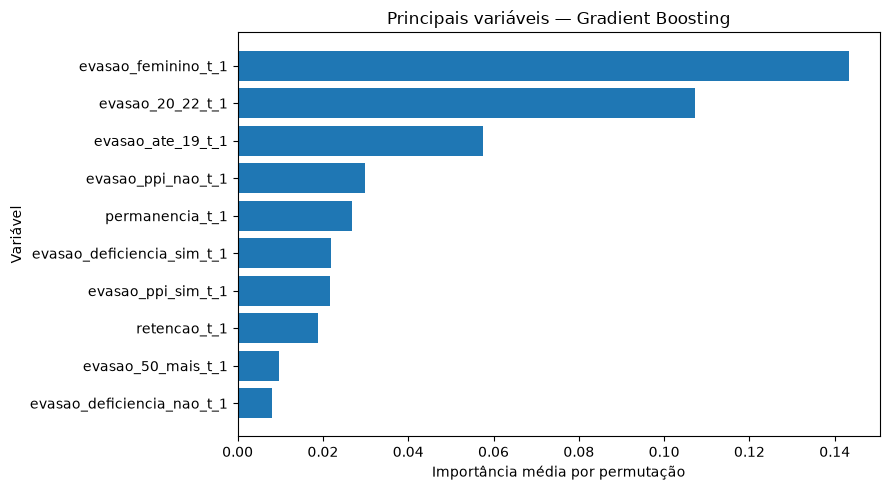

In [12]:
top_features = (
    resumo_permutacao
    .head(10)
    .sort_values("media_importancia")
)

plt.figure(figsize=(9, 5))

plt.barh(
    top_features["feature"],
    top_features["media_importancia"]
)

plt.xlabel(
    "Importância média por permutação"
)

plt.ylabel(
    "Variável"
)

plt.title(
    "Principais variáveis — Gradient Boosting"
)

plt.tight_layout()
plt.show()

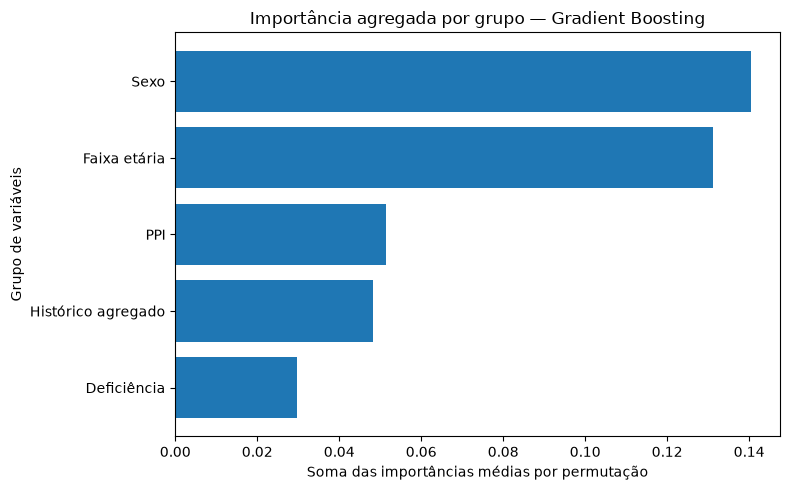

In [13]:
grupo_plot = (
    importancia_por_grupo
    .sort_values("soma")
)

plt.figure(figsize=(8, 5))

plt.barh(
    grupo_plot.index,
    grupo_plot["soma"]
)

plt.xlabel(
    "Soma das importâncias médias por permutação"
)

plt.ylabel(
    "Grupo de variáveis"
)

plt.title(
    "Importância agregada por grupo — Gradient Boosting"
)

plt.tight_layout()
plt.show()

In [14]:
estabilidade_importancia = (
    importancias_nativas
    .groupby("feature")["importance"]
    .agg(
        media="mean",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .sort_values(
        "media",
        ascending=False
    )
    .round(4)
)

estabilidade_importancia

,media,desvio_padrao,minimo,maximo
feature,,,,
evasao_20_22_t_1,0.2562,0.1920,0.0560,0.4388
evasao_feminino_t_1,0.2057,0.1795,0.0685,0.4089
evasao_ate_19_t_1,0.1138,0.0843,0.0178,0.1759
evasao_40_49_t_1,0.0604,0.0250,0.0329,0.0817
retencao_t_1,0.0445,0.0320,0.0216,0.0810
conclusao_t_1,0.0409,0.0187,0.0254,0.0618
evasao_deficiencia_nao_t_1,0.0366,0.0074,0.0292,0.0439
evasao_25_29_t_1,0.0348,0.0167,0.0250,0.0541
evasao_50_mais_t_1,0.0282,0.0166,0.0092,0.0396


## 6.6 Estabilidade da importância por fold

In [15]:
estabilidade_permutacao = (
    importancias_permutacao
    .groupby("feature")["importance_mean"]
    .agg(
        media="mean",
        desvio_padrao="std",
        minimo="min",
        maximo="max"
    )
    .sort_values(
        "media",
        ascending=False
    )
    .round(4)
)

estabilidade_permutacao

,media,desvio_padrao,minimo,maximo
feature,,,,
evasao_feminino_t_1,0.1434,0.0278,0.1152,0.1708
evasao_20_22_t_1,0.1073,0.0960,-0.0003,0.1841
evasao_ate_19_t_1,0.0576,0.0519,0.0197,0.1168
evasao_ppi_nao_t_1,0.0298,0.0394,-0.0021,0.0739
permanencia_t_1,0.0268,0.0954,-0.0755,0.1133
evasao_deficiencia_sim_t_1,0.0219,0.0318,-0.0052,0.0569
evasao_ppi_sim_t_1,0.0216,0.0189,0.0097,0.0434
retencao_t_1,0.0188,0.0225,-0.0040,0.0411
evasao_50_mais_t_1,0.0097,0.0109,0.0021,0.0223


In [16]:
importancias_permutacao["importancia_positiva"] = (
    importancias_permutacao["importance_mean"] > 0
)

estabilidade_folds = (
    importancias_permutacao
    .groupby("feature")
    .agg(
        folds_positivos=(
            "importancia_positiva",
            "sum"
        ),
        importancia_media=(
            "importance_mean",
            "mean"
        ),
        desvio_padrao=(
            "importance_mean",
            "std"
        )
    )
    .sort_values(
        ["folds_positivos", "importancia_media"],
        ascending=False
    )
    .round(4)
)

estabilidade_folds

,folds_positivos,importancia_media,desvio_padrao
feature,,,
evasao_feminino_t_1,3,0.1434,0.0278
evasao_ate_19_t_1,3,0.0576,0.0519
evasao_ppi_sim_t_1,3,0.0216,0.0189
evasao_50_mais_t_1,3,0.0097,0.0109
evasao_t_1,3,0.0068,0.0073
evasao_20_22_t_1,2,0.1073,0.0960
evasao_ppi_nao_t_1,2,0.0298,0.0394
permanencia_t_1,2,0.0268,0.0954
evasao_deficiencia_sim_t_1,2,0.0219,0.0318


In [17]:
estabilidade_folds["amplitude"] = (
    estabilidade_folds["importancia_media"] * 0
)

In [18]:
estabilidade_permutacao["amplitude"] = (
    estabilidade_permutacao["maximo"]
    - estabilidade_permutacao["minimo"]
)

estabilidade_permutacao.sort_values(
    "media",
    ascending=False
).round(4)

,media,desvio_padrao,minimo,maximo,amplitude
feature,,,,,
evasao_feminino_t_1,0.1434,0.0278,0.1152,0.1708,0.0556
evasao_20_22_t_1,0.1073,0.0960,-0.0003,0.1841,0.1844
evasao_ate_19_t_1,0.0576,0.0519,0.0197,0.1168,0.0971
evasao_ppi_nao_t_1,0.0298,0.0394,-0.0021,0.0739,0.0760
permanencia_t_1,0.0268,0.0954,-0.0755,0.1133,0.1888
evasao_deficiencia_sim_t_1,0.0219,0.0318,-0.0052,0.0569,0.0621
evasao_ppi_sim_t_1,0.0216,0.0189,0.0097,0.0434,0.0337
retencao_t_1,0.0188,0.0225,-0.0040,0.0411,0.0451
evasao_50_mais_t_1,0.0097,0.0109,0.0021,0.0223,0.0202


In [19]:
importancias_permutacao[
    importancias_permutacao["feature"].isin([
        "evasao_feminino_t_1",
        "evasao_20_22_t_1",
        "evasao_ate_19_t_1",
        "evasao_ppi_sim_t_1",
        "permanencia_t_1",
        "evasao_t_1"
    ])
].sort_values(
    ["feature", "fold"]
).round(4)

,feature,importance_mean,importance_std,fold,periodo_teste,importancia_positiva
9,evasao_20_22_t_1,0.1841,0.1402,1,2021,True
26,evasao_20_22_t_1,0.1380,0.0850,2,2022,True
43,evasao_20_22_t_1,-0.0003,0.0343,3,2023,False
8,evasao_ate_19_t_1,0.0197,0.0100,1,2021,True
25,evasao_ate_19_t_1,0.1168,0.0722,2,2022,True
42,evasao_ate_19_t_1,0.0364,0.0409,3,2023,True
4,evasao_feminino_t_1,0.1152,0.0746,1,2021,True
21,evasao_feminino_t_1,0.1443,0.0576,2,2022,True
38,evasao_feminino_t_1,0.1708,0.0698,3,2023,True
6,evasao_ppi_sim_t_1,0.0434,0.0147,1,2021,True


## 6.7 Resumo metodológico da análise

O experimento foi estruturado como uma validação temporal comparativa da
previsão da taxa de evasão nas unidades federativas brasileiras.

A base analítica foi construída a partir dos Indicadores de Fluxo da
Educação Superior disponibilizados pelo INEP. Foram utilizadas informações
referentes às 27 unidades federativas e aos períodos de fluxo disponíveis
entre 2017–2018 e 2023–2024 para a construção do conjunto experimental.

A variável-alvo foi definida como a taxa de evasão no período t (`evasao_t`).
As variáveis preditoras foram utilizadas com defasagem temporal, de modo que
as informações empregadas para prever t pertencem ao período anterior (t-1).
Essa estrutura foi adotada para evitar o uso de informações futuras na
construção das previsões.

Foram definidos dois cenários experimentais:

- Cenário A: utilização de quatro indicadores agregados do período anterior:
  taxa de evasão, conclusão, retenção e permanência.

- Cenário B: utilização dos quatro indicadores agregados do Cenário A,
  acrescidos de taxas de evasão desagregadas por sexo, PPI, faixa etária e
  deficiência, totalizando 17 variáveis preditoras.

A validação foi realizada por dois protocolos temporais:

- Expanding Window: o conjunto de treinamento incorpora todo o histórico
  disponível antes de cada período de teste.

- Rolling Window: o treinamento utiliza uma janela fixa de quatro períodos
  anteriores ao período de teste.

Os dois protocolos utilizam os mesmos períodos de teste:
2021–2022, 2022–2023 e 2023–2024, com as mesmas 27 unidades federativas em
cada período. Dessa forma, a comparação entre os protocolos altera apenas a
quantidade de histórico utilizada no treinamento.

Foram avaliadas cinco abordagens:

1. Persistência, utilizada como baseline;
2. Regressão Linear;
3. Regressão Ridge;
4. Random Forest;
5. Gradient Boosting.

Todos os modelos supervisionados foram treinados separadamente em cada fold
temporal. No caso da Regressão Ridge, a padronização das variáveis foi
realizada dentro de um pipeline ajustado exclusivamente sobre os dados de
treinamento de cada fold.

O desempenho foi avaliado por três métricas:

- MAE (Mean Absolute Error);
- RMSE (Root Mean Squared Error);
- R² (coeficiente de determinação).

Além das métricas agregadas, foram analisados os resultados por período de
teste e a distribuição dos erros das previsões.

Para o Cenário B, foi realizada uma análise complementar de interpretabilidade
do modelo Gradient Boosting. Foram utilizadas a importância interna das
variáveis e a importância por permutação, calculada nos conjuntos de teste
de cada fold. A estabilidade dessas importâncias também foi examinada entre
os três períodos avaliados.

A análise de interpretabilidade é de natureza preditiva e exploratória.
As importâncias observadas não são interpretadas como efeitos causais das
variáveis sobre a evasão. Além disso, a interpretação das importâncias por
permutação deve ser considerada com cautela em razão do número reduzido de
observações por conjunto de teste e da possível correlação entre variáveis
desagregadas.

O desenho experimental busca, portanto, avaliar não apenas o desempenho médio
dos modelos, mas também sua estabilidade temporal, o comportamento dos erros
e o efeito da inclusão de informações desagregadas na capacidade preditiva.

## 6.7 Exportação das importâncias por fold

In [20]:
CAMINHO_IMPORTANCIAS_GB = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "importancias_gb_cenario_b_expanding.csv"
)

importancias_permutacao.to_csv(
    CAMINHO_IMPORTANCIAS_GB,
    index=False
)

print(
    f"Importâncias salvas em:\n{CAMINHO_IMPORTANCIAS_GB}"
)

Importâncias salvas em:
/home/sara/Documentos/tcc-evasao-ensino-superior/results/tables/importancias_gb_cenario_b_expanding.csv
